In [1]:

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot
)
from shap_rtl import RTLSHAPExplainer


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew


In [13]:
# ============================================================
# COMPLETE BAR PLOT TEST - HEBREW
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: SETUP PATH
# ============================================================

CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

# ============================================================
# STEP 2: IMPORT RTL PLOTS
# ============================================================

from shap_rtl.plots import bar
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW BAR PLOT TEST")
print("="*80)

# ============================================================
# STEP 3: LOAD DATA
# ============================================================

print("\n📂 Loading Hebrew data...")

# Load Hebrew data
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(200)
    print(f"✅ Loaded {len(df)} samples (first 200)")

# Identify columns
text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 4: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

# Map labels if needed
if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

# Drop rows with empty text
df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 5: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=2000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 6: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 7: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 8: COMPUTE SHAP VALUES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES")
print("="*80)

# Vectorize the sample
vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

# Get SHAP values
shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

# Sort by absolute SHAP value
sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 9: CREATE SHAP EXPLANATION FOR BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CREATING SHAP EXPLANATION FOR BAR PLOT")
print("="*80)

max_features = 8

# Get top features
top_features = sorted_features[:max_features]
top_shap = sorted_shap[:max_features]
top_data = present_data[:max_features]

# Create SHAP Explanation
shap_exp = shap.Explanation(
    values=top_shap,
    base_values=shap_values.base_values[0],
    data=top_data,
    feature_names=top_features
)

print(f"\n📊 SHAP Explanation created with {len(top_features)} features:")
for name, val in zip(top_features, top_shap):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 10: GENERATE BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 GENERATING RTL BAR PLOT")
print("="*80)

print("\n📋 Flow:")
print("   1️⃣  Hebrew Bar Plot (displayed now)")
print("   2️⃣  Hebrew Explanation (you'll be prompted)")
print("   3️⃣  English Bar Plot (you'll be asked)")
print("   4️⃣  English Explanation (you'll be asked)")
print("-"*80)

# Generate the bar plot using RTL explainer
explainer_rtl.run_full_analysis(
    shap_values=shap_exp,
    prediction_label=class_names[1],
    plot_fn=bar,
    max_features=max_features,
    sample_text=sample_text,
    allow_positive_negative_split=True
)

print("\n" + "="*80)
print("✅ BAR PLOT COMPLETE!")
print("="*80)

ImportError: cannot import name 'render_mixed_label' from 'shap_rtl.rtl_utils' (c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\rtl_utils.py)

[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew
📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

📝 Sample text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[WARNING] No Hebrew font found.
[INFO] RTL text may not display correctly in plots.
[INFO] To fix: Download 'NotoSansHebrew-Regular.ttf'
[INFO] and place it in the 'fonts' directory or pass as custom_font_path

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: default
   Translations: Enabled → English
   Max features to transla

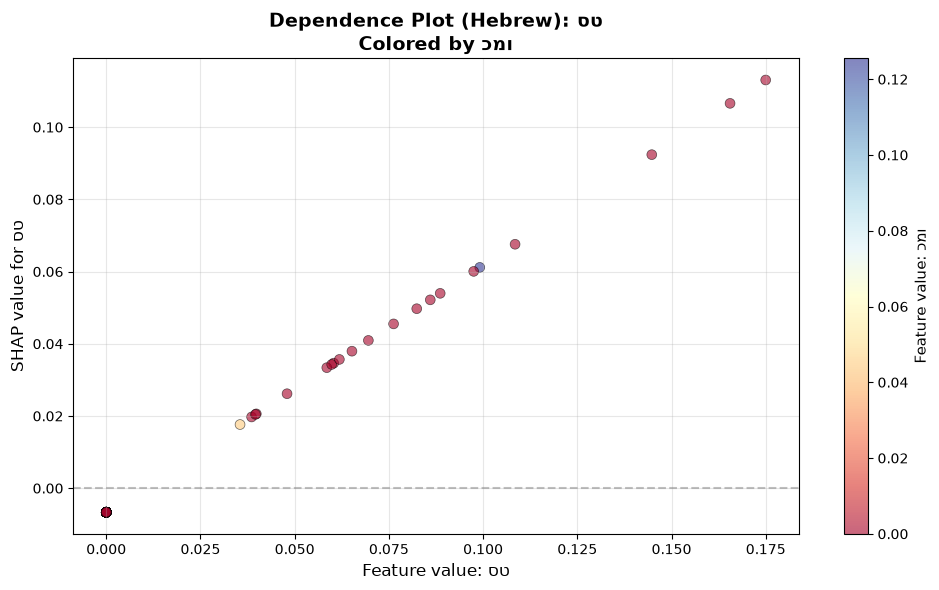


[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: VIOLENCE
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
--------------------------------------------------

Feature: סט | Value: +0.0050
----------------------------------------
המאפיין "סט" משפיע חיובית על החיזוי "VIOLENCE" משום שבהקשרים מסוימים, המילה "סט" יכולה להתייחס לקבוצה או לחבורה, ובמצבים מסוימים, קבוצות או חבורות יכולות להיות מעורבות באלימות. כתוצאה מכך, הופעת המילה "סט" בטקסט יכולה לשקף נוכחות של אלימות או איום, ולכן היא תורמת לחיזוי "VIOLENCE" באופן חיובי.
----------------------------------------


[INFO] Generating English plo

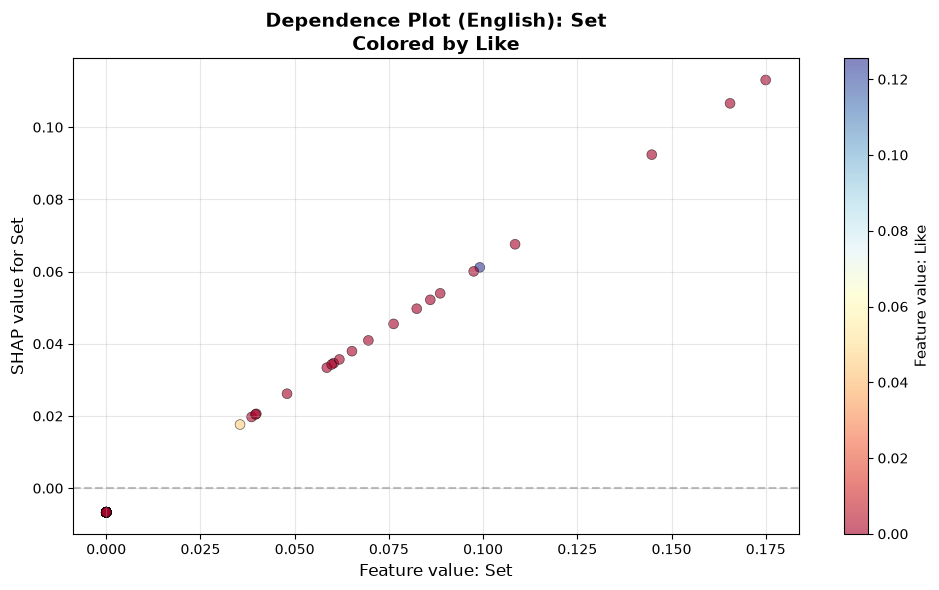


                              ENGLISH EXPLANATIONS                              

Translated Sample: נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                              PREDICTION: Violence                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: סט | Value: +0.0050
----------------------------------------
The Hebrew feature 'סט' (SHAP value: +0.0050) has a slight positive impact on the model's prediction of 'VIOLENCE', suggesting that the presence of this feature in the input data increases the likelihood of the model outputting 'VIOLENCE'. This could be due to the feature 'סט

In [3]:
# ============================================================
# HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS - COMPLETE TEST
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.plots import bar, waterfall, beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer
from shap_rtl.explainer import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW DEPENDENCE PLOT WITH RTL TRANSLATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR SAMPLE")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(100, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 100 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CHOOSE FEATURES FOR DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CHOOSING FEATURES FOR DEPENDENCE PLOT")
print("="*80)

# Choose the top feature for dependence plot
top_feature = sorted_features[0]
top_feature_idx = feature_names.index(top_feature)

# Choose a second feature for coloring
second_feature = sorted_features[1] if len(sorted_features) > 1 else top_feature
second_feature_idx = feature_names.index(second_feature)

print(f"\n📊 Selected features:")
print(f"   Main feature: '{top_feature}' (SHAP: {sorted_shap[0]:+.4f})")
print(f"   Color by: '{second_feature}'")
print("-"*60)

# Get data for selected features
feature1_data = data_all[:, top_feature_idx]
feature1_shap = shap_values_all[:, top_feature_idx]
feature2_data = data_all[:, second_feature_idx]

# ============================================================
# STEP 9: CREATE DEPENDENCE PLOT DATA
# ============================================================

print("\n" + "="*80)
print("📊 CREATING DEPENDENCE PLOT DATA")
print("="*80)

# Use top 5 features for the SHAP Explanation
num_features_for_plot = min(5, len(sorted_features))
top_features_for_plot = sorted_features[:num_features_for_plot]
top_indices_for_plot = [feature_names.index(f) for f in top_features_for_plot]

# Get SHAP values for these features
top_shap_for_plot = shap_values_all[:, top_indices_for_plot]
top_data_for_plot = data_all[:, top_indices_for_plot]
top_names_for_plot = top_features_for_plot

print(f"\n📊 Using {num_features_for_plot} features:")
for i, name in enumerate(top_names_for_plot):
    mean_shap = np.mean(shap_values_all[:, feature_names.index(name)])
    print(f"   {i+1}. {name} (mean SHAP: {mean_shap:+.4f})")
print("-"*60)

# Create SHAP Explanation with multiple features
shap_exp_multi = shap.Explanation(
    values=top_shap_for_plot,
    base_values=np.mean(top_shap_for_plot, axis=0),
    data=top_data_for_plot,
    feature_names=top_names_for_plot
)

print(f"\n📊 SHAP Explanation created:")
print(f"   Values shape: {shap_exp_multi.values.shape}")
print(f"   Feature names: {shap_exp_multi.feature_names}")

# ============================================================
# STEP 10: RUN RTL EXPLAINER WITH DEPENDENCE PLOT
# ============================================================

print("\n" + "="*80)
print("🎨 RUNNING RTL EXPLAINER WITH DEPENDENCE PLOT")
print("="*80)

print("\n📋 Flow:")
print("   1. Hebrew dependence plot will be shown")
print("   2. You'll be asked: How many features to explain in Hebrew?")
print("   3. Hebrew explanation will be generated")
print("   4. You'll be asked: Would you like to see the plot in English?")
print("   5. English dependence plot (with translated feature names) will be shown")
print("   6. You'll be asked: Would you like explanation in English?")
print("   7. English explanation will be generated")
print("-"*60)

# This will follow the full flow:
# RTL Plot → RTL Explanation → English Plot → English Explanation
try:
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_multi,
        prediction_label=class_names[1],
        plot_fn=None,  # ← No plot function = dependence plot
        max_features=5,
        sample_text=sample_text,
        allow_positive_negative_split=True,
        features=top_data_for_plot  # ← Pass features for dependence plot
    )
except Exception as e:
    print(f"[WARNING] Dependence plot failed: {e}")
    print("\n📌 Falling back to direct explanation...")
    
    # ============================================================
    # FALLBACK: Direct Explanations Without Plot
    # ============================================================
    
    print("\n" + "="*80)
    print("📊 DIRECT EXPLANATIONS (FALLBACK)")
    print("="*80)
    
    # Translate sample
    eng_sample = explainer_rtl._translate_sample(sample_text)
    eng_label = explainer_rtl._translate_label(class_names[1])
    
    print(f"\n📝 Sample Translation:")
    print(f"   {eng_sample}")
    print("-"*60)
    
    for i, feat in enumerate(top_names_for_plot[:3]):
        eng_feature = explainer_rtl._translate_features([feat])[0]
        shap_val = np.mean(shap_values_all[:, feature_names.index(feat)])
        
        print(f"\n{i+1}. Feature: {feat}")
        print(f"   English: {eng_feature}")
        print(f"   Mean SHAP: {shap_val:+.4f}")
        
        # Get English explanation
        try:
            prompt = explainer_rtl._eng_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1],
                eng_translation=eng_label
            )
            response = explainer_rtl._invoke_llm(prompt)
            print(f"\n   📝 English Explanation:")
            print(f"   {response}")
        except Exception as e2:
            print(f"   ⚠️ Could not generate English explanation: {e2}")
        
        # Get Hebrew explanation
        try:
            prompt = explainer_rtl._rtl_prompt(
                feat_name=feat,
                shap_val=shap_val,
                prediction_label=class_names[1]
            )
            response = explainer_rtl._invoke_llm(prompt)
            fixed_response = explainer_rtl._fix_for_terminal(response)
            print(f"\n   📝 Hebrew Explanation:")
            print(f"   {fixed_response}")
        except Exception as e3:
            print(f"   ⚠️ Could not generate Hebrew explanation: {e3}")
        
        print("-"*60)

# ============================================================
# STEP 11: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Correlation
correlation = np.corrcoef(feature1_data, feature1_shap)[0, 1]

print(f"\n📊 Feature: '{top_feature}'")
print(f"   Mean SHAP value: {np.mean(feature1_shap):+.4f}")
print(f"   Correlation with SHAP: {correlation:.3f}")
print(f"   Positive SHAP in {np.mean(feature1_shap > 0)*100:.1f}% of samples")

if correlation > 0.3:
    print(f"   ✅ Strong positive correlation: Higher feature value → Higher SHAP (→ VIOLENCE)")
elif correlation < -0.3:
    print(f"   ✅ Strong negative correlation: Higher feature value → Lower SHAP (→ NOT)")
else:
    print(f"   ⚖️ Weak correlation: Feature doesn't clearly predict direction")

# Class-wise analysis
violence_shap = feature1_shap[labels_all == 1] if np.sum(labels_all == 1) > 0 else []
not_shap = feature1_shap[labels_all == 0] if np.sum(labels_all == 0) > 0 else []

if len(violence_shap) > 0 and len(not_shap) > 0:
    print(f"\n📊 Class-wise Analysis:")
    print(f"   VIOLENCE samples: {np.mean(violence_shap):+.4f} (n={len(violence_shap)})")
    print(f"   NOT samples:      {np.mean(not_shap):+.4f} (n={len(not_shap)})")
    
    if np.mean(violence_shap) > np.mean(not_shap):
        print(f"   ✅ Feature is more positive in VIOLENCE samples")
    else:
        print(f"   ✅ Feature is more negative in NOT samples")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)
print("\n💡 Summary:")
print("   • Hebrew dependence plot shown first")
print("   • English dependence plot shown when requested")
print("   • Hebrew and English explanations generated")
print("   • All translations use the RTL explainer")

📊 HEBREW BAR PLOT WITH RTL TRANSLATIONS

📂 Loading cleaned data...
✅ Loaded cleaned data: 1000 samples
📝 Text column: clean_text
🏷️ Label column: label

📝 Sample text:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים...

🔧 PREPARING DATA

📊 Dataset Statistics:
  NOT Violence: 863 (86.3%)
  VIOLENCE: 137 (13.7%)

🔧 TRAINING MODEL
✅ Model trained!
   Train Accuracy: 0.9543
   Test Accuracy: 0.8067
   Total features: 3000

🔤 SETUP RTL EXPLAINER
[WARNING] No Hebrew font found.
[INFO] RTL text may not display correctly in plots.
[INFO] To fix: Download 'NotoSansHebrew-Regular.ttf'
[INFO] and place it in the 'fonts' directory or pass as custom_font_path

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: default
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!

🎯 GETTING VIOLENCE SAMPLE

📝 VIOLENCE Sample:
   נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית

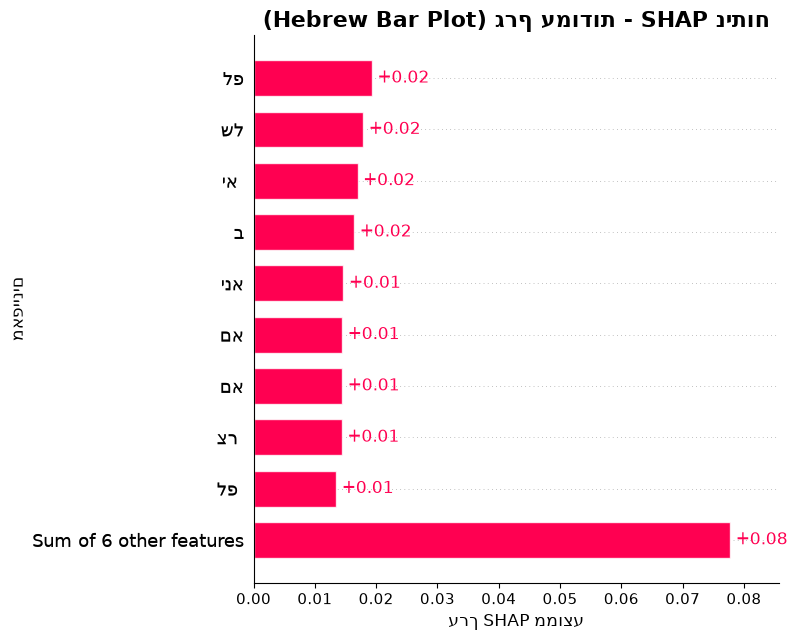

✅ Hebrew bar plot displayed!

🎨 RUNNING RTL EXPLAINER WITH BAR PLOT

📋 Flow:
   1. Hebrew bar plot shown above
   2. You'll be asked: How many features to explain in Hebrew?
   3. Hebrew explanation will be generated
   4. You'll be asked: Would you like to see the bar plot in English?
   5. English bar plot (with translated feature names) will be shown
   6. You'll be asked: Would you like explanation in English?
   7. English explanation will be generated
------------------------------------------------------------

                            HEBREW SHAP EXPLANATIONS                            
                              Prediction: VIOLENCE                              

[GENERATING HEBREW SHAP PLOT...]


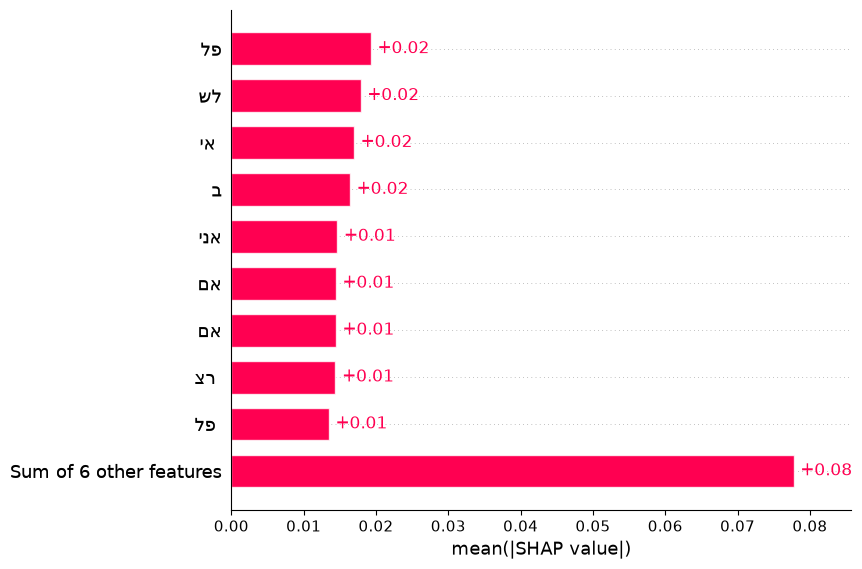


[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: VIOLENCE
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
--------------------------------------------------

Feature: פל | Value: +0.0014
----------------------------------------
המאפיין "פל" משפיע חיובית על החיזוי "VIOLENCE" משום שבעברית, המילה "פל" יכולה להתייחס לנשק או לכלי לחימה, כגון "פל רובה" או "פל חרב", ולכן הופעתה בטקסט עלולה לרמז על אלימות או גילוי נטייה לאלימות, מה שמצדיק את החיזוי החיובי של "VIOLENCE".
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TRANSL

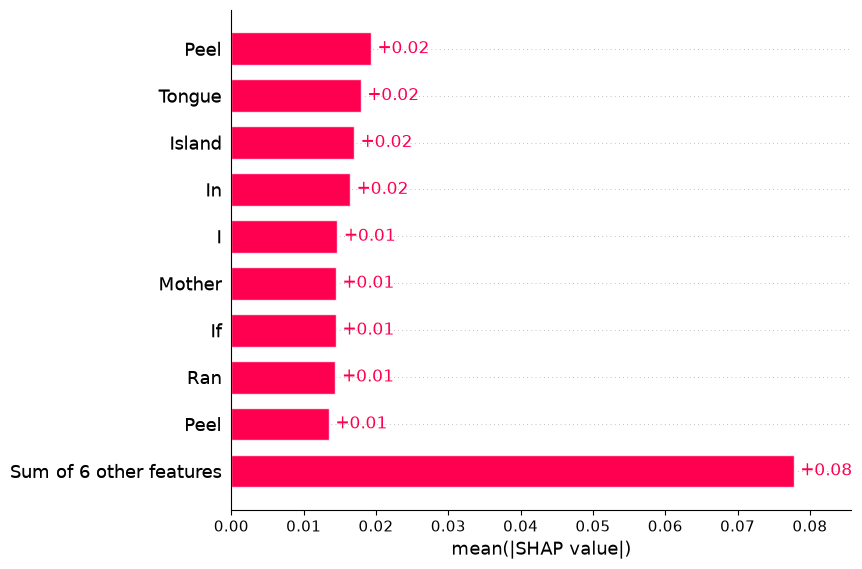


                              ENGLISH EXPLANATIONS                              

Translated Sample: It seems to me that the case reminds you of your good old days in the hills where you were a racist terrorist like them, isn't there a bit of nostalgia in hard times
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                              PREDICTION: Violence                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Peel | Value: +0.0014
----------------------------------------
The Hebrew feature 'Peel' has a minor positive impact on the model's prediction of 'VIOLENCE', as indicated by its SHAP value of +0.0014. This suggests that when the word 'Peel' is present, the model is slightly m

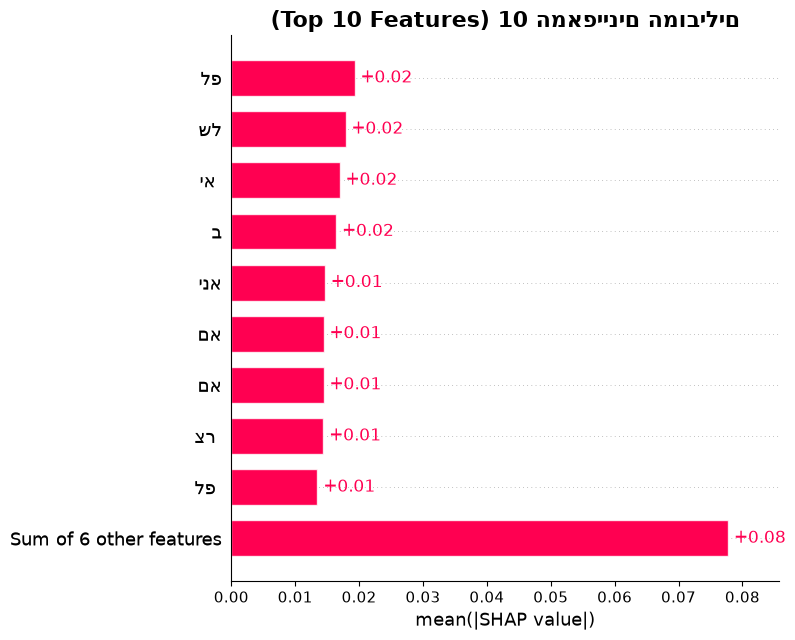


2️⃣ Bar plots split by class (VIOLENCE vs NOT)


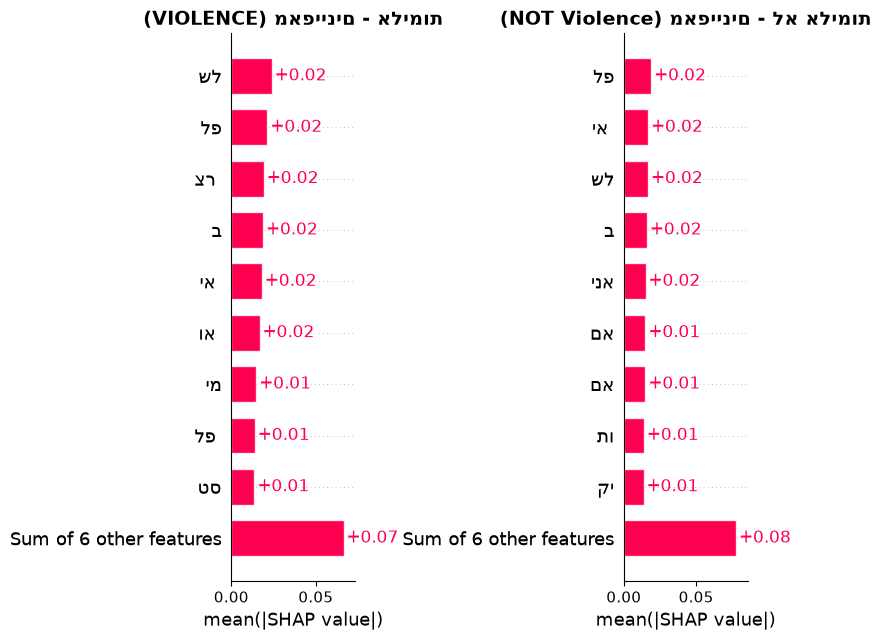


📊 INTERPRETATION SUMMARY

📊 Top 5 Most Important Features:
------------------------------------------------------------

1. Feature: 'פל'
   Mean |SHAP|: 0.0193
   VIOLENCE mean SHAP: +0.0054
   NOT mean SHAP: +0.0007
   🔴 More important for VIOLENCE detection

2. Feature: 'לש'
   Mean |SHAP|: 0.0179
   VIOLENCE mean SHAP: +0.0111
   NOT mean SHAP: +0.0021
   🔴 More important for VIOLENCE detection

3. Feature: ' אי'
   Mean |SHAP|: 0.0170
   VIOLENCE mean SHAP: +0.0016
   NOT mean SHAP: +0.0044
   🟢 More important for NOT violence detection

4. Feature: 'ב '
   Mean |SHAP|: 0.0164
   VIOLENCE mean SHAP: -0.0048
   NOT mean SHAP: +0.0047
   🔴 More important for VIOLENCE detection

5. Feature: 'אני'
   Mean |SHAP|: 0.0147
   VIOLENCE mean SHAP: +0.0007
   NOT mean SHAP: -0.0029
   🟢 More important for NOT violence detection

✅ BAR PLOT ANALYSIS COMPLETE!

💡 Summary:
   • Hebrew bar plot displayed with RTL support
   • English bar plot shown with translated feature names
   • Hebrew and

In [2]:
# ============================================================
# HEBREW BAR PLOT WITH RTL TRANSLATIONS - COMPLETE TEST
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear caches
gc.collect()
plt.close('all')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

# Import RTL package
from shap_rtl.explainer import RTLSHAPExplainer

print("="*80)
print("📊 HEBREW BAR PLOT WITH RTL TRANSLATIONS")
print("="*80)

# ============================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================

print("\n📂 Loading cleaned data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded cleaned data: {len(df)} samples")
except FileNotFoundError:
    print(f"⚠️ File not found, loading full data...")
    full_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv'
    df = pd.read_csv(full_path)
    df = df.head(500)
    print(f"✅ Loaded {len(df)} samples (first 500)")

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

print(f"📝 Text column: {text_col}")
print(f"🏷️ Label column: {label_col}")

# Show sample
print(f"\n📝 Sample text:")
print(f"   {df[text_col].iloc[0][:150]}...")

# ============================================================
# STEP 2: PREPARE DATA
# ============================================================

print("\n" + "="*80)
print("🔧 PREPARING DATA")
print("="*80)

if df[label_col].dtype == 'object':
    def map_label(label):
        label_lower = str(label).lower().strip()
        violence_keywords = ['violence', 'violent', 'hate', 'abusive', 'hate,', 'violence,', 'racism']
        for keyword in violence_keywords:
            if keyword in label_lower:
                return 1
        return 0 if label_lower in ['not', '0'] else 0
    df['label'] = df[label_col].apply(map_label)
else:
    df['label'] = df[label_col].astype(int)

df = df[df[text_col].str.len() > 0]
df = df.dropna(subset=[text_col, 'label'])

class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

print(f"\n📊 Dataset Statistics:")
for class_id, name in class_names.items():
    count = (df['label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df['label'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    analyzer='char',
    max_features=3000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    random_state=42, 
    C=1.0,
    solver='liblinear'
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"   Train Accuracy: {model.score(X_train_vec, y_train):.4f}")
print(f"   Test Accuracy: {model.score(X_test_vec, y_test):.4f}")

feature_names = list(vectorizer.get_feature_names_out())
print(f"   Total features: {len(feature_names)}")

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

# Create RTL explainer for Hebrew
explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    max_features_to_translate=50
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: GET VIOLENCE SAMPLE
# ============================================================

print("\n" + "="*80)
print("🎯 GETTING VIOLENCE SAMPLE")
print("="*80)

violence_samples = df[df['label'] == 1][text_col].head(2).tolist()

if violence_samples:
    sample_text = violence_samples[0]
    print(f"\n📝 VIOLENCE Sample:")
    print(f"   {sample_text[:150]}...")
else:
    print("❌ No VIOLENCE samples found!")
    exit()

# ============================================================
# STEP 6: COMPUTE SHAP VALUES FOR SAMPLE
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR SAMPLE")
print("="*80)

vec = vectorizer.transform([sample_text]).toarray()[0]
present_idx = np.where(vec > 0)[0]

if len(present_idx) == 0:
    print("❌ No features found in text!")
    exit()

shap_values = shap_explainer(vec.reshape(1, -1))

present_feature_names = [feature_names[i] for i in present_idx]
present_shap_values = shap_values.values[0][present_idx]
present_data = vec[present_idx]

sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
sorted_features = [present_feature_names[i] for i in sorted_idx]
sorted_shap = present_shap_values[sorted_idx]

print(f"\n📊 Top features in this sample:")
print("-"*60)
for i, (name, val) in enumerate(zip(sorted_features[:10], sorted_shap[:10])):
    direction = "→ VIOLENCE" if val > 0 else "→ NOT"
    print(f"  {i+1}. '{name}': {val:+.4f} {direction}")

# ============================================================
# STEP 7: GET SHAP VALUES FOR MULTIPLE SAMPLES (FOR BAR PLOT)
# ============================================================

print("\n" + "="*80)
print("📊 COMPUTING SHAP VALUES FOR MULTIPLE SAMPLES (BAR PLOT)")
print("="*80)

# Get SHAP values for multiple samples
shap_values_all = []
data_all = []
labels_all = []

sample_indices = np.random.choice(len(X_test_vec), min(50, len(X_test_vec)), replace=False)

print("📊 Computing SHAP values for 50 samples...")
for idx in sample_indices:
    vec_sample = X_test_vec[idx]
    if np.sum(vec_sample) > 0:
        shap_val = shap_explainer(vec_sample.reshape(1, -1))
        shap_values_all.append(shap_val.values[0])
        data_all.append(vec_sample)
        labels_all.append(y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx])

if not shap_values_all:
    print("❌ No SHAP values computed!")
    exit()

shap_values_all = np.array(shap_values_all)
data_all = np.array(data_all)
labels_all = np.array(labels_all)

print(f"✅ Computed SHAP values for {len(shap_values_all)} samples")

# ============================================================
# STEP 8: CREATE BAR PLOT WITH TOP FEATURES
# ============================================================

print("\n" + "="*80)
print("📊 SELECTING TOP FEATURES FOR BAR PLOT")
print("="*80)

# Calculate mean absolute SHAP values across all samples
mean_abs_shap = np.mean(np.abs(shap_values_all), axis=0)
top_n = 15  # Number of features to show in bar plot
top_indices = np.argsort(mean_abs_shap)[::-1][:top_n]

top_feature_names = [feature_names[i] for i in top_indices]
top_shap_values = shap_values_all[:, top_indices]
top_data_values = data_all[:, top_indices]

print(f"\n📊 Top {top_n} features (by mean |SHAP|):")
print("-"*60)
for i, (name, val) in enumerate(zip(top_feature_names, mean_abs_shap[top_indices])):
    print(f"  {i+1:2d}. '{name}': {val:.4f}")

# ============================================================
# STEP 9: CREATE SHAP EXPLANATION FOR BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 CREATING SHAP EXPLANATION FOR BAR PLOT")
print("="*80)

# Create SHAP Explanation object for bar plot
shap_exp_bar = shap.Explanation(
    values=top_shap_values,
    base_values=np.mean(shap_explainer.expected_value) if hasattr(shap_explainer, 'expected_value') else np.mean(shap_values_all),
    data=top_data_values,
    feature_names=top_feature_names
)

print(f"✅ SHAP Explanation created:")
print(f"   Values shape: {shap_exp_bar.values.shape}")
print(f"   Features: {len(top_feature_names)}")

# ============================================================
# STEP 10: DISPLAY HEBREW BAR PLOT FIRST
# ============================================================

print("\n" + "="*80)
print("🎨 DISPLAYING HEBREW BAR PLOT")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.bar(shap_exp_bar, show=False)
ax.set_title(explainer_rtl._fix_for_plot('ניתוח SHAP - גרף עמודות (Hebrew Bar Plot)'), 
             fontsize=16, fontweight='bold')
ax.set_xlabel(explainer_rtl._fix_for_plot('ערך SHAP ממוצע'), fontsize=12)
ax.set_ylabel(explainer_rtl._fix_for_plot('מאפיינים'), fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Hebrew bar plot displayed!")

# ============================================================
# STEP 11: RUN RTL EXPLAINER WITH BAR PLOT
# ============================================================

print("\n" + "="*80)
print("🎨 RUNNING RTL EXPLAINER WITH BAR PLOT")
print("="*80)

print("\n📋 Flow:")
print("   1. Hebrew bar plot shown above")
print("   2. You'll be asked: How many features to explain in Hebrew?")
print("   3. Hebrew explanation will be generated")
print("   4. You'll be asked: Would you like to see the bar plot in English?")
print("   5. English bar plot (with translated feature names) will be shown")
print("   6. You'll be asked: Would you like explanation in English?")
print("   7. English explanation will be generated")
print("-"*60)

# This will follow the full flow:
# Bar Plot → RTL Explanation → English Bar Plot → English Explanation
try:
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_bar,
        prediction_label=class_names[1],
        plot_fn=shap.plots.bar,  # ← Bar plot function
        max_features=10,
        sample_text=sample_text,
        allow_positive_negative_split=True
    )
except Exception as e:
    print(f"[WARNING] Bar plot flow failed: {e}")
    print("\n📌 Falling back to direct explanation...")
    
    # ============================================================
    # FALLBACK: Direct Explanations
    # ============================================================
    
    print("\n" + "="*80)
    print("📊 DIRECT EXPLANATIONS (FALLBACK)")
    print("="*80)
    
    # Translate sample
    eng_sample = explainer_rtl._translate_sample(sample_text)
    eng_label = explainer_rtl._translate_label(class_names[1])
    
    print(f"\n📝 Sample Translation:")
    print(f"   {eng_sample[:150]}...")
    print("-"*60)
    
    # Display English bar plot
    print("\n📊 DISPLAYING ENGLISH BAR PLOT")
    print("-"*60)
    
    eng_feature_names = explainer_rtl._translate_features(top_feature_names[:10])
    eng_shap = explainer_rtl._rebuild_explanation_with_names(shap_exp_bar, eng_feature_names)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.bar(eng_shap, show=False)
    ax.set_title('SHAP Analysis - Bar Plot (English)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Generate explanations for top features
    print("\n📊 FEATURE EXPLANATIONS")
    print("="*60)
    
    for i, feat in enumerate(top_feature_names[:5]):
        eng_feature = explainer_rtl._translate_features([feat])[0]
        shap_val = mean_abs_shap[top_indices[i]]
        
        print(f"\n{i+1}. Feature: {feat}")
        print(f"   English Translation: {eng_feature}")
        print(f"   Mean |SHAP|: {shap_val:.4f}")
        
        # Get English explanation
        try:
            prompt = explainer_rtl._eng_prompt(
                feat_name=feat,
                shap_val=float(np.mean(top_shap_values[:, i])),
                prediction_label=class_names[1],
                eng_translation=eng_label
            )
            response = explainer_rtl._invoke_llm(prompt)
            print(f"\n   📝 English Explanation:")
            print(f"   {response[:200]}...")
        except Exception as e2:
            print(f"   ⚠️ Could not generate English explanation: {e2}")
        
        # Get Hebrew explanation
        try:
            prompt = explainer_rtl._rtl_prompt(
                feat_name=feat,
                shap_val=float(np.mean(top_shap_values[:, i])),
                prediction_label=class_names[1]
            )
            response = explainer_rtl._invoke_llm(prompt)
            fixed_response = explainer_rtl._fix_for_terminal(response)
            print(f"\n   📝 Hebrew Explanation:")
            print(f"   {fixed_response[:200]}...")
        except Exception as e3:
            print(f"   ⚠️ Could not generate Hebrew explanation: {e3}")
        
        print("-"*60)

# ============================================================
# STEP 12: ADDITIONAL BAR PLOT VISUALIZATIONS
# ============================================================

print("\n" + "="*80)
print("📊 ADDITIONAL BAR PLOT VISUALIZATIONS")
print("="*80)

# 1. Bar plot with max display
print("\n1️⃣ Bar plot with max_display=10")
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.bar(shap_exp_bar, max_display=10, show=False)
ax.set_title(explainer_rtl._fix_for_plot('10 המאפיינים המובילים (Top 10 Features)'), 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Bar plot split by class
print("\n2️⃣ Bar plots split by class (VIOLENCE vs NOT)")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# VIOLENCE samples
violence_mask = labels_all == 1
if np.sum(violence_mask) > 0:
    violence_shap = shap.Explanation(
        values=top_shap_values[violence_mask],
        base_values=shap_exp_bar.base_values,
        data=top_data_values[violence_mask],
        feature_names=top_feature_names
    )
    plt.sca(axes[0])
    shap.plots.bar(violence_shap, max_display=10, show=False)
    axes[0].set_title(explainer_rtl._fix_for_plot('מאפיינים - אלימות (VIOLENCE)'), 
                      fontsize=14, fontweight='bold')

# NOT violence samples
not_mask = labels_all == 0
if np.sum(not_mask) > 0:
    not_shap = shap.Explanation(
        values=top_shap_values[not_mask],
        base_values=shap_exp_bar.base_values,
        data=top_data_values[not_mask],
        feature_names=top_feature_names
    )
    plt.sca(axes[1])
    shap.plots.bar(not_shap, max_display=10, show=False)
    axes[1].set_title(explainer_rtl._fix_for_plot('מאפיינים - לא אלימות (NOT Violence)'), 
                      fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# STEP 13: INTERPRETATION SUMMARY
# ============================================================

print("\n" + "="*80)
print("📊 INTERPRETATION SUMMARY")
print("="*80)

# Top features analysis
print(f"\n📊 Top 5 Most Important Features:")
print("-"*60)

for i in range(min(5, len(top_feature_names))):
    feature_name = top_feature_names[i]
    feature_idx = top_indices[i]
    
    # Calculate class-specific means
    if np.sum(violence_mask) > 0:
        mean_violence = np.mean(top_shap_values[violence_mask, i])
    else:
        mean_violence = 0
        
    if np.sum(not_mask) > 0:
        mean_not = np.mean(top_shap_values[not_mask, i])
    else:
        mean_not = 0
    
    print(f"\n{i+1}. Feature: '{feature_name}'")
    print(f"   Mean |SHAP|: {mean_abs_shap[feature_idx]:.4f}")
    print(f"   VIOLENCE mean SHAP: {mean_violence:+.4f}")
    print(f"   NOT mean SHAP: {mean_not:+.4f}")
    
    if abs(mean_violence) > abs(mean_not):
        print(f"   🔴 More important for VIOLENCE detection")
    else:
        print(f"   🟢 More important for NOT violence detection")

print("\n" + "="*80)
print("✅ BAR PLOT ANALYSIS COMPLETE!")
print("="*80)
print("\n💡 Summary:")
print("   • Hebrew bar plot displayed with RTL support")
print("   • English bar plot shown with translated feature names")
print("   • Hebrew and English explanations generated")
print("   • Class-specific analysis provided")
print("   • All translations use the RTL explainer")
print("\n📊 Key Insights:")
print(f"   • Top feature: '{top_feature_names[0]}'")
print(f"   • Most important for: {'VIOLENCE' if abs(np.mean(top_shap_values[violence_mask, 0])) > abs(np.mean(top_shap_values[not_mask, 0])) else 'NOT violence'}")
print(f"   • Total features analyzed: {len(top_feature_names)}")

[WARNING] No Hebrew font found.
[INFO] RTL text may not display correctly in plots.
[INFO] To fix: Download 'NotoSansHebrew-Regular.ttf'
[INFO] and place it in the 'fonts' directory or pass as custom_font_path

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: default
   Translations: Disabled (fast)
   Max features to translate: 50

📊 TEST 1: BAR PLOT


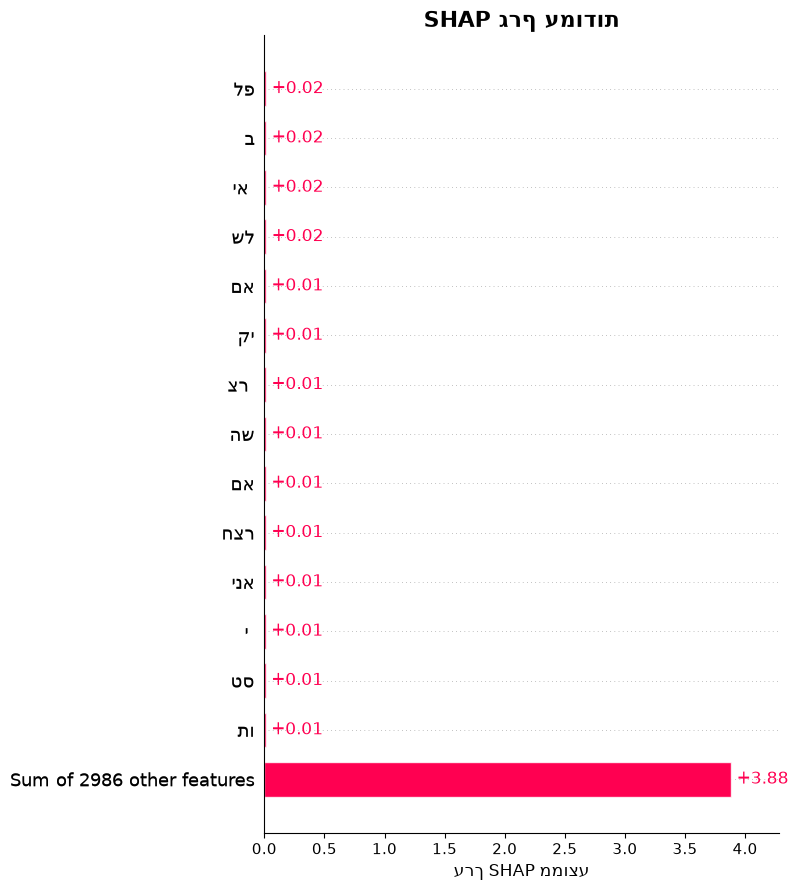

In [3]:
# ============================================================
# HEBREW SHAP PLOTS - COMPLETE TESTING SUITE
# ============================================================

import sys
import os
import gc
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

gc.collect()
plt.close('all')

# Setup paths
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
if os.path.exists(os.path.join(PARENT_PROJECT_ROOT, "src")):
    sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))
sys.path.insert(0, PARENT_PROJECT_ROOT)

from shap_rtl.explainer import RTLSHAPExplainer

# ============================================================
# LOAD DATA
# ============================================================
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_sample.csv'

try:
    df = pd.read_csv(file_path)
except:
    df = pd.read_csv(r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\hebrew_cleaned_full.csv').head(500)

text_col = 'clean_text' if 'clean_text' in df.columns else 'TweetText'
label_col = 'label' if 'label' in df.columns else 'Label'

if df[label_col].dtype == 'object':
    df['label'] = df[label_col].apply(lambda x: 1 if any(k in str(x).lower() for k in ['violence', 'violent', 'hate', 'abusive', 'racism']) else 0)
else:
    df['label'] = df[label_col].astype(int)

df = df.dropna(subset=[text_col, 'label'])
class_names = {0: 'NOT Violence', 1: 'VIOLENCE'}

# ============================================================
# TRAIN MODEL
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(df[text_col], df['label'], test_size=0.3, random_state=42, stratify=df['label'])

vectorizer = TfidfVectorizer(ngram_range=(1, 3), analyzer='char', max_features=3000, min_df=2, max_df=0.95, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, C=1.0, solver='liblinear').fit(X_train_vec, y_train)
feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# SETUP SHAP & RTL EXPLAINER
# ============================================================
masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq",
    skip_translation=True,  # Skip API calls for faster testing
    max_features_to_translate=50
)

# ============================================================
# PREPARE DATA FOR PLOTS
# ============================================================
n_samples = 50
indices = np.random.choice(len(X_test_vec), min(n_samples, len(X_test_vec)), replace=False)
shap_multi = shap_explainer(X_test_vec[indices])
shap_multi.feature_names = feature_names
shap_multi.data = X_test_vec[indices]

single_idx = 0
shap_single = shap_explainer(X_test_vec[single_idx:single_idx+1])
shap_single.feature_names = feature_names
shap_single.data = X_test_vec[single_idx:single_idx+1]

# ============================================================
# TEST 1: BAR PLOT
# ============================================================
print("📊 TEST 1: BAR PLOT")
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.bar(shap_multi, max_display=15, show=False)
ax.set_title(explainer_rtl._fix_for_plot('גרף עמודות SHAP'), fontsize=16, fontweight='bold')
ax.set_xlabel(explainer_rtl._fix_for_plot('ערך SHAP ממוצע'), fontsize=12)
plt.tight_layout()
plt.show()


📊 TEST 2: WATERFALL PLOT


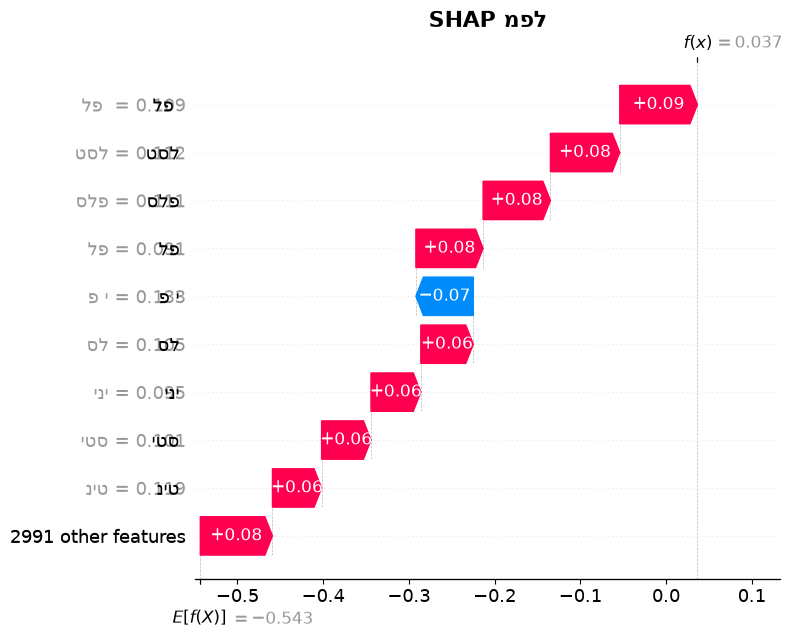

In [4]:

# ============================================================
# TEST 2: WATERFALL PLOT
# ============================================================
print("📊 TEST 2: WATERFALL PLOT")
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(shap_single[0], max_display=10, show=False)
ax.set_title(explainer_rtl._fix_for_plot('מפל SHAP'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 TEST 3: BEESWARM PLOT


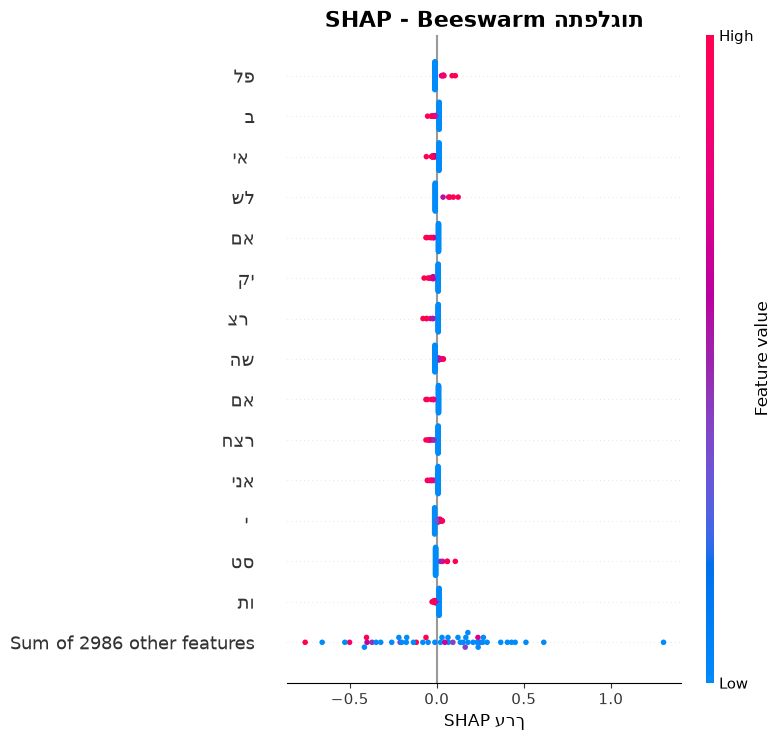

In [5]:

# ============================================================
# TEST 3: BEESWARM PLOT
# ============================================================
print("📊 TEST 3: BEESWARM PLOT")
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.beeswarm(shap_multi, max_display=15, show=False)
ax.set_title(explainer_rtl._fix_for_plot('התפלגות SHAP - Beeswarm'), fontsize=16, fontweight='bold')
ax.set_xlabel(explainer_rtl._fix_for_plot('ערך SHAP'), fontsize=12)
plt.tight_layout()
plt.show()


📊 TEST 4: HEATMAP PLOT


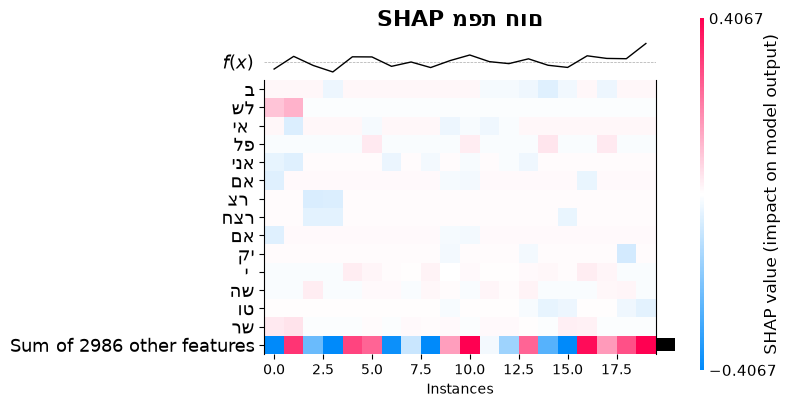

In [6]:

# ============================================================
# TEST 4: HEATMAP PLOT
# ============================================================
print("📊 TEST 4: HEATMAP PLOT")
fig, ax = plt.subplots(figsize=(14, 10))
shap.plots.heatmap(shap_multi[:20], max_display=15, show=False)
ax.set_title(explainer_rtl._fix_for_plot('מפת חום SHAP'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 TEST 5: DECISION PLOT


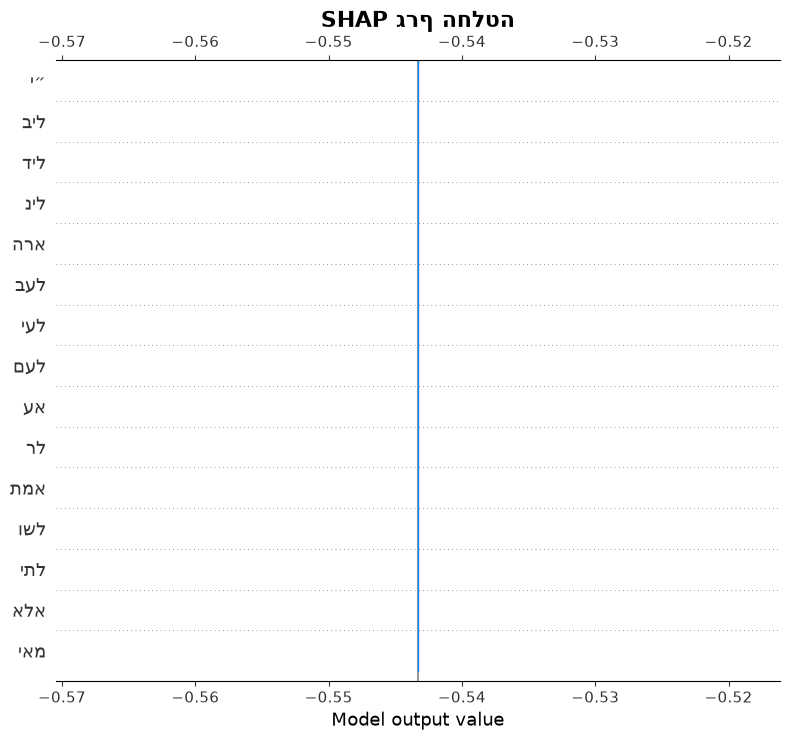

In [7]:

# ============================================================
# TEST 5: DECISION PLOT
# ============================================================
print("📊 TEST 5: DECISION PLOT")
fig, ax = plt.subplots(figsize=(12, 8))
shap.decision_plot(
    shap_single.base_values[0],
    shap_single.values[0],
    feature_names,
    feature_display_range=slice(None, 15, 1),
    show=False
)
ax.set_title(explainer_rtl._fix_for_plot('גרף החלטה SHAP'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 TEST 6: FORCE PLOT


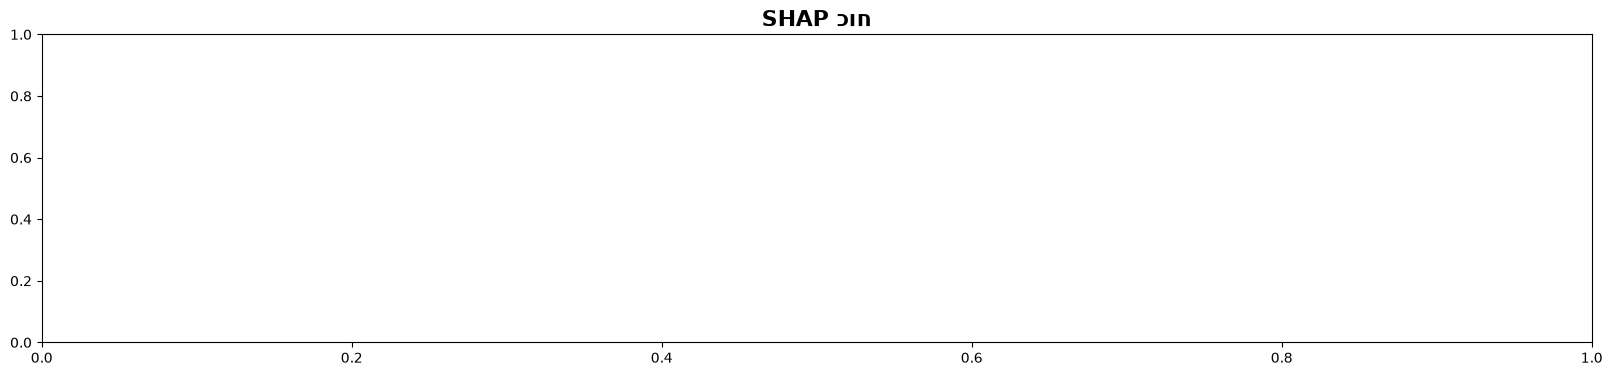

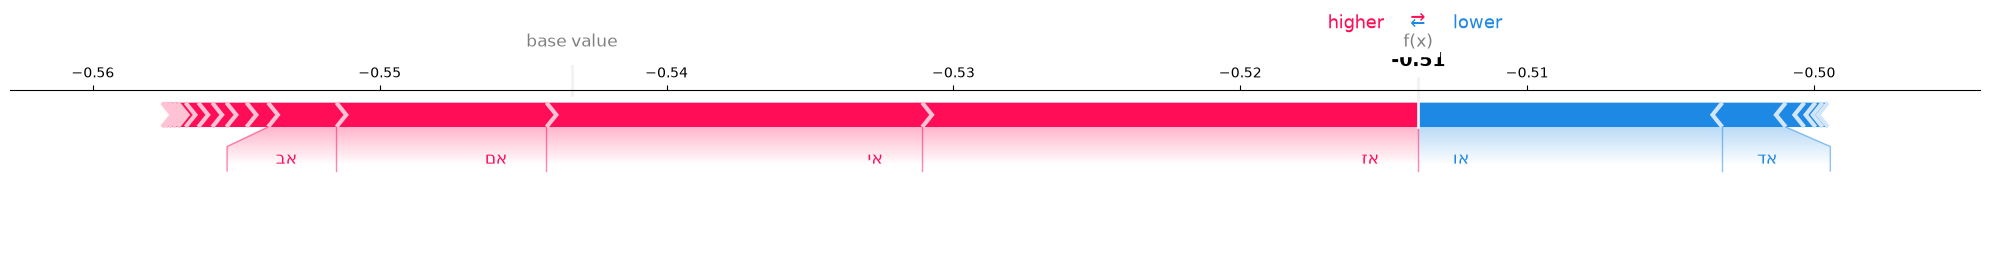

📊 TEST 7: SUMMARY PLOT (BAR)


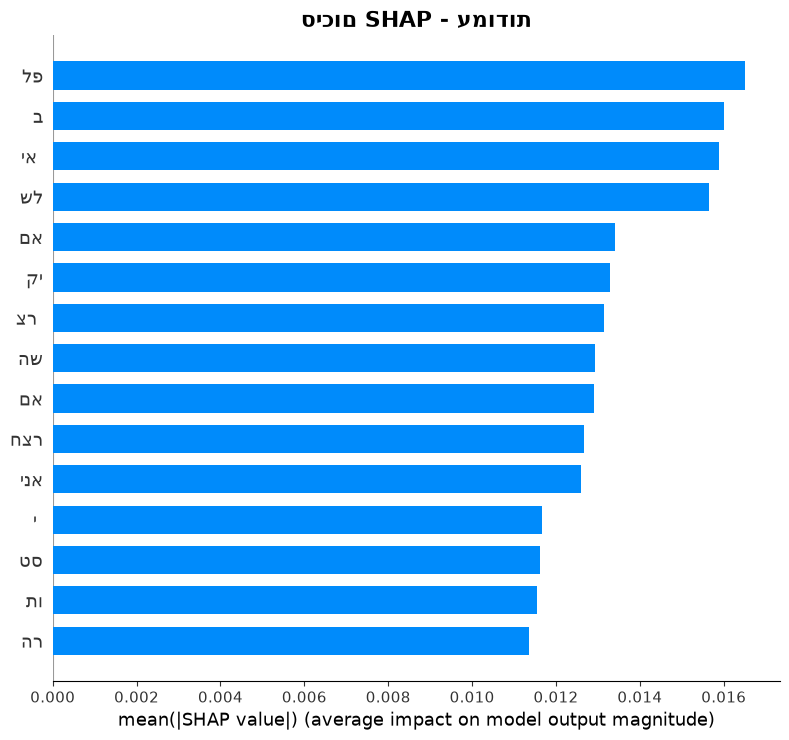

📊 TEST 8: SUMMARY PLOT (DOT)


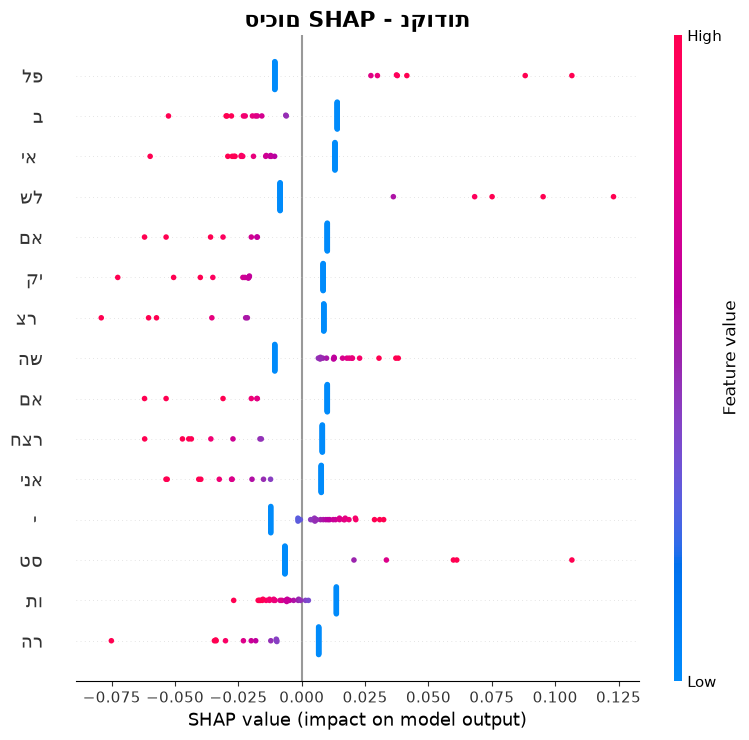

📊 TEST 9: DEPENDENCE PLOT


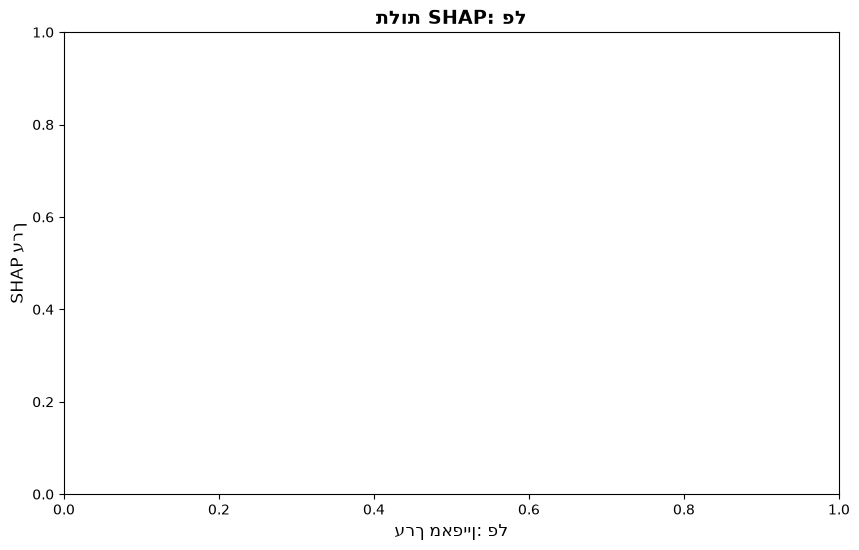

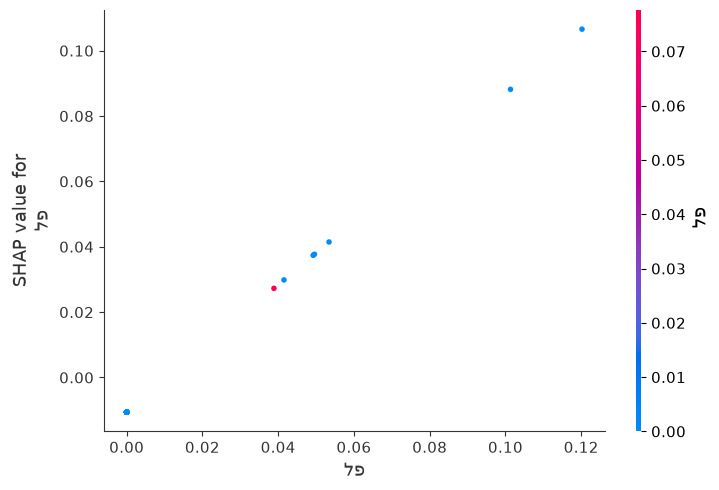

📊 TEST 10: ALL PLOTS GRID


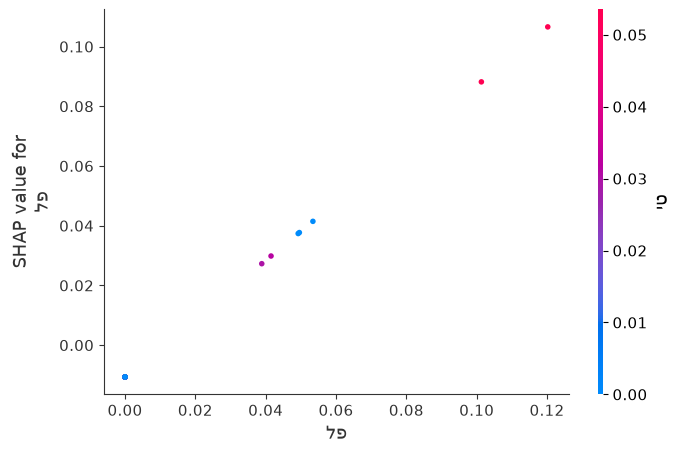

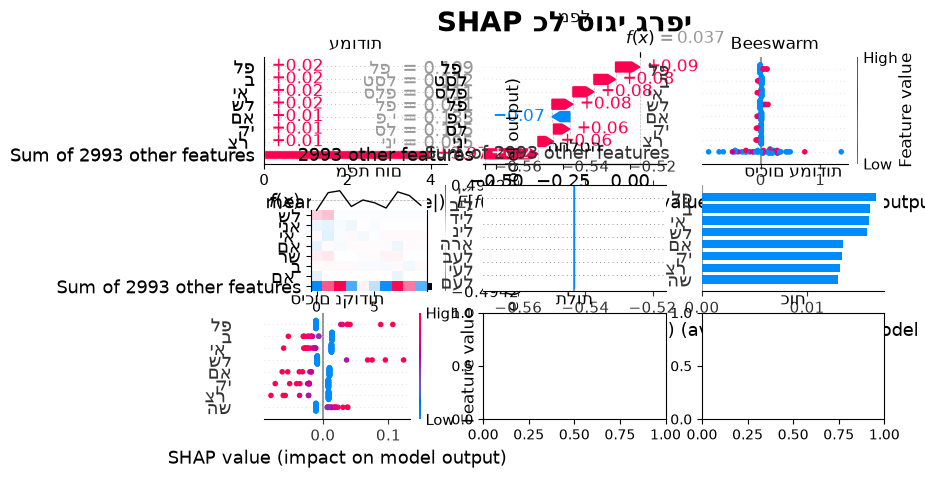

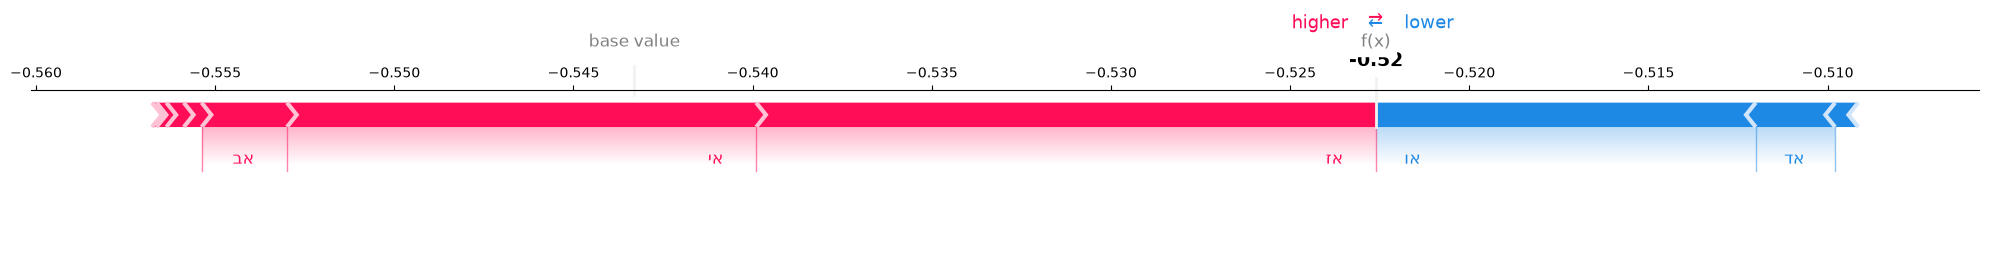

📊 TEST 11: CLASS-SPECIFIC PLOTS


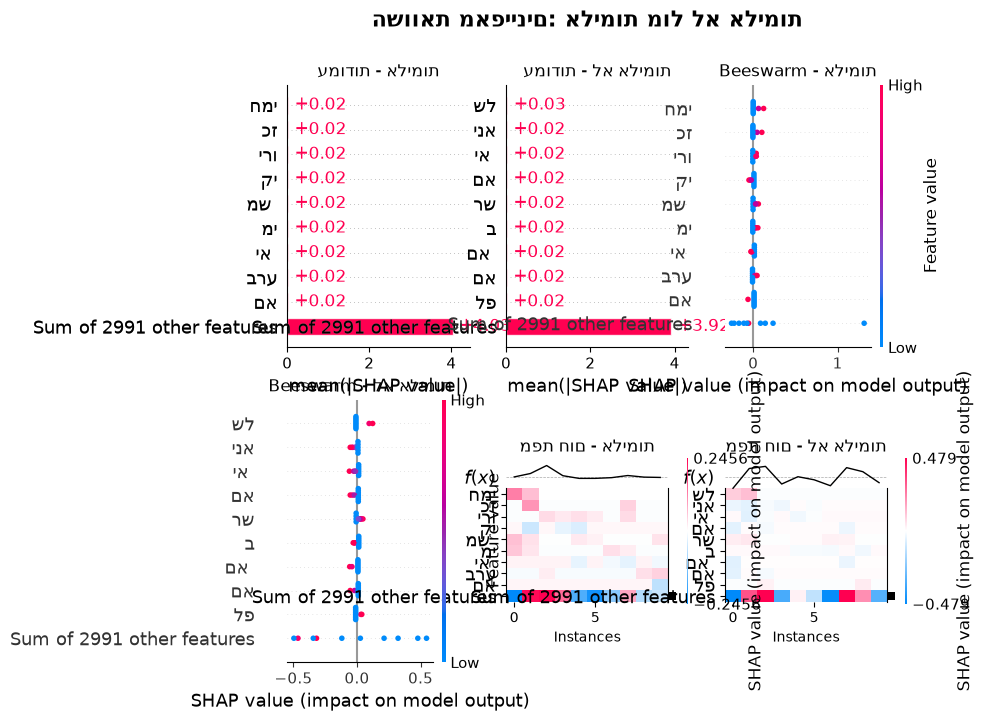

📊 TEST 12: FULL ANALYSIS WITH BAR PLOT

                            HEBREW SHAP EXPLANATIONS                            
                              Prediction: VIOLENCE                              

[GENERATING HEBREW SHAP PLOT...]


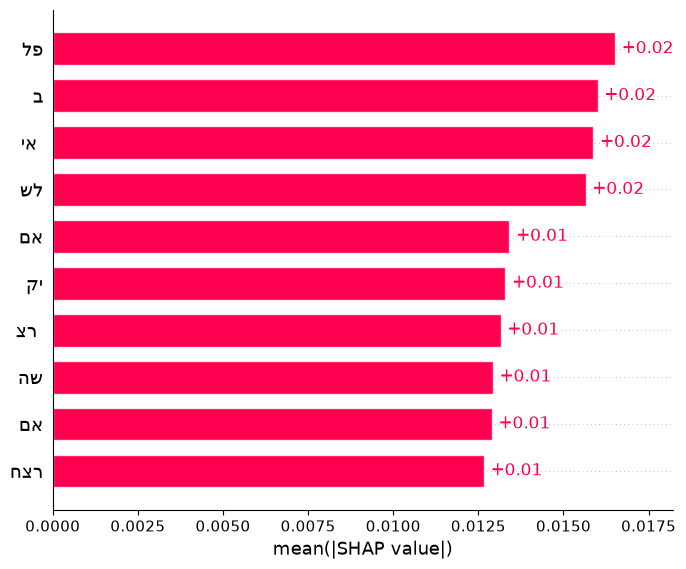


[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                    PREDICTION: VIOLENCE
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
--------------------------------------------------

Feature: פל | Value: -0.0018
----------------------------------------
                                                                                                                        
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TRANSLATING SAMPLE TEXT TO ENGLISH...]
[WARNING] Could not translate sample text.
Translated Prediction Label: VIOLENCE

[GE

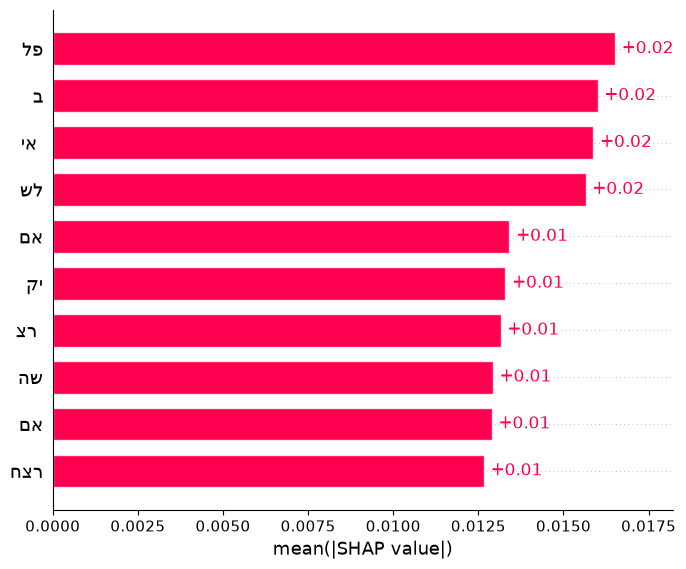


                              ENGLISH EXPLANATIONS                              

Translated Sample: נראה לי שהמקרה מזכיר לך את ימך היפים בגבעות שהיית טרוריסט גזען כמוהם לא אין כמו קצת נוסטלגיה בזמנים קשים
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                              PREDICTION: VIOLENCE                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: פל | Value: -0.0018
----------------------------------------

----------------------------------------

Analysis complete.

[INFO] Exiting. Thank you!

📊 TEST 13: FULL ANALYSIS WITH WATERFALL

                            HEBREW SHAP EXPLANATIONS                            
                              Prediction: VIOLENCE             

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (1, 10)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [8]:

# ============================================================
# TEST 6: FORCE PLOT (matplotlib version)
# ============================================================
print("📊 TEST 6: FORCE PLOT")
fig, ax = plt.subplots(figsize=(20, 4))
shap.plots.force(
    shap_single.base_values[0],
    shap_single.values[0][:20],
    feature_names[:20],
    matplotlib=True,
    show=False
)
ax.set_title(explainer_rtl._fix_for_plot('כוח SHAP'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# TEST 7: SUMMARY PLOT - BAR
# ============================================================
print("📊 TEST 7: SUMMARY PLOT (BAR)")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_multi.values, shap_multi.data, feature_names=feature_names, plot_type="bar", max_display=15, show=False)
ax.set_title(explainer_rtl._fix_for_plot('סיכום SHAP - עמודות'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# TEST 8: SUMMARY PLOT - DOT
# ============================================================
print("📊 TEST 8: SUMMARY PLOT (DOT)")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_multi.values, shap_multi.data, feature_names=feature_names, max_display=15, show=False)
ax.set_title(explainer_rtl._fix_for_plot('סיכום SHAP - נקודות'), fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# TEST 9: DEPENDENCE PLOT
# ============================================================
print("📊 TEST 9: DEPENDENCE PLOT")
top_feature_idx = np.argmax(np.mean(np.abs(shap_multi.values), axis=0))
second_feature_idx = (top_feature_idx + 1) % shap_multi.values.shape[1]

fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx,
    shap_multi.values,
    shap_multi.data,
    feature_names=feature_names,
    interaction_index=second_feature_idx,
    show=False
)
ax.set_title(explainer_rtl._fix_for_plot(f'תלות SHAP: {feature_names[top_feature_idx]}'), fontsize=14, fontweight='bold')
ax.set_xlabel(explainer_rtl._fix_for_plot(f'ערך מאפיין: {feature_names[top_feature_idx]}'), fontsize=12)
ax.set_ylabel(explainer_rtl._fix_for_plot('ערך SHAP'), fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# TEST 10: ALL PLOTS SUBPLOT GRID
# ============================================================
print("📊 TEST 10: ALL PLOTS GRID")
fig = plt.figure(figsize=(20, 16))
fig.suptitle(explainer_rtl._fix_for_plot('כל סוגי גרפי SHAP'), fontsize=20, fontweight='bold')

# Bar
ax1 = fig.add_subplot(3, 3, 1)
plt.sca(ax1)
shap.plots.bar(shap_multi, max_display=8, show=False)
ax1.set_title(explainer_rtl._fix_for_plot('עמודות'), fontsize=12)

# Waterfall
ax2 = fig.add_subplot(3, 3, 2)
plt.sca(ax2)
shap.plots.waterfall(shap_single[0], max_display=8, show=False)
ax2.set_title(explainer_rtl._fix_for_plot('מפל'), fontsize=12)

# Beeswarm
ax3 = fig.add_subplot(3, 3, 3)
plt.sca(ax3)
shap.plots.beeswarm(shap_multi, max_display=8, show=False)
ax3.set_title(explainer_rtl._fix_for_plot('Beeswarm'), fontsize=12)

# Heatmap
ax4 = fig.add_subplot(3, 3, 4)
plt.sca(ax4)
shap.plots.heatmap(shap_multi[:10], max_display=8, show=False)
ax4.set_title(explainer_rtl._fix_for_plot('מפת חום'), fontsize=12)

# Decision
ax5 = fig.add_subplot(3, 3, 5)
plt.sca(ax5)
shap.decision_plot(shap_single.base_values[0], shap_single.values[0], feature_names, 
                   feature_display_range=slice(None, 8, 1), show=False)
ax5.set_title(explainer_rtl._fix_for_plot('החלטה'), fontsize=12)

# Summary Bar
ax6 = fig.add_subplot(3, 3, 6)
plt.sca(ax6)
shap.summary_plot(shap_multi.values, shap_multi.data, feature_names=feature_names, 
                  plot_type="bar", max_display=8, show=False)
ax6.set_title(explainer_rtl._fix_for_plot('סיכום עמודות'), fontsize=12)

# Summary Dot
ax7 = fig.add_subplot(3, 3, 7)
plt.sca(ax7)
shap.summary_plot(shap_multi.values, shap_multi.data, feature_names=feature_names, 
                  max_display=8, show=False)
ax7.set_title(explainer_rtl._fix_for_plot('סיכום נקודות'), fontsize=12)

# Dependence
ax8 = fig.add_subplot(3, 3, 8)
plt.sca(ax8)
shap.dependence_plot(top_feature_idx, shap_multi.values, shap_multi.data, 
                     feature_names=feature_names, show=False)
ax8.set_title(explainer_rtl._fix_for_plot('תלות'), fontsize=12)

# Force
ax9 = fig.add_subplot(3, 3, 9)
plt.sca(ax9)
shap.plots.force(shap_single.base_values[0], shap_single.values[0][:10], 
                 feature_names[:10], matplotlib=True, show=False)
ax9.set_title(explainer_rtl._fix_for_plot('כוח'), fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================
# TEST 11: CLASS-SPECIFIC PLOTS
# ============================================================
print("📊 TEST 11: CLASS-SPECIFIC PLOTS")

y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
labels = y_test_array[indices]

violence_idx = np.where(labels == 1)[0][:10] if np.sum(labels == 1) > 0 else []
not_idx = np.where(labels == 0)[0][:10] if np.sum(labels == 0) > 0 else []

if len(violence_idx) > 0 and len(not_idx) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(explainer_rtl._fix_for_plot('השוואת מאפיינים: אלימות מול לא אלימות'), fontsize=16, fontweight='bold')
    
    # Violence - Bar
    plt.sca(axes[0, 0])
    shap.plots.bar(shap_multi[violence_idx], max_display=10, show=False)
    axes[0, 0].set_title(explainer_rtl._fix_for_plot('עמודות - אלימות'), fontsize=12)
    
    # Not Violence - Bar
    plt.sca(axes[0, 1])
    shap.plots.bar(shap_multi[not_idx], max_display=10, show=False)
    axes[0, 1].set_title(explainer_rtl._fix_for_plot('עמודות - לא אלימות'), fontsize=12)
    
    # Violence - Beeswarm
    plt.sca(axes[0, 2])
    shap.plots.beeswarm(shap_multi[violence_idx], max_display=10, show=False)
    axes[0, 2].set_title(explainer_rtl._fix_for_plot('Beeswarm - אלימות'), fontsize=12)
    
    # Not Violence - Beeswarm
    plt.sca(axes[1, 0])
    shap.plots.beeswarm(shap_multi[not_idx], max_display=10, show=False)
    axes[1, 0].set_title(explainer_rtl._fix_for_plot('Beeswarm - לא אלימות'), fontsize=12)
    
    # Violence - Heatmap
    plt.sca(axes[1, 1])
    shap.plots.heatmap(shap_multi[violence_idx], max_display=10, show=False)
    axes[1, 1].set_title(explainer_rtl._fix_for_plot('מפת חום - אלימות'), fontsize=12)
    
    # Not Violence - Heatmap
    plt.sca(axes[1, 2])
    shap.plots.heatmap(shap_multi[not_idx], max_display=10, show=False)
    axes[1, 2].set_title(explainer_rtl._fix_for_plot('מפת חום - לא אלימות'), fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# TEST 12: RUN FULL ANALYSIS WITH BAR PLOT
# ============================================================
print("📊 TEST 12: FULL ANALYSIS WITH BAR PLOT")

sample_text = df[text_col].iloc[0]
top_n = 10
mean_abs = np.mean(np.abs(shap_multi.values), axis=0)
top_indices = np.argsort(mean_abs)[::-1][:top_n]
top_names = [feature_names[i] for i in top_indices]

shap_exp = shap.Explanation(
    values=shap_multi.values[:, top_indices],
    base_values=shap_multi.base_values,
    data=shap_multi.data[:, top_indices],
    feature_names=top_names
)

explainer_rtl.run_full_analysis(
    shap_values=shap_exp,
    prediction_label=class_names[1],
    plot_fn=shap.plots.bar,
    max_features=10,
    sample_text=sample_text
)

# ============================================================
# TEST 13: RUN FULL ANALYSIS WITH WATERFALL
# ============================================================
print("\n📊 TEST 13: FULL ANALYSIS WITH WATERFALL")

waterfall_shap = shap.Explanation(
    values=shap_single.values[:, top_indices],
    base_values=shap_single.base_values,
    data=shap_single.data[:, top_indices],
    feature_names=top_names
)

explainer_rtl.run_full_analysis(
    shap_values=waterfall_shap,
    prediction_label=class_names[1],
    plot_fn=shap.plots.waterfall,
    max_features=5,
    sample_text=sample_text
)

# ============================================================
# TEST 14: FEATURE IMPORTANCE TABLE
# ============================================================
print("\n📊 TEST 14: FEATURE IMPORTANCE TABLE")

importance_df = pd.DataFrame({
    'Feature': top_names,
    'Mean |SHAP|': mean_abs[top_indices],
    'Mean SHAP': np.mean(shap_multi.values[:, top_indices], axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print(importance_df.to_string(index=False))

# ============================================================
# COMPLETE
# ============================================================
print("\n✅ All Hebrew SHAP plot tests complete!")
print("   ✓ Bar Plot")
print("   ✓ Waterfall Plot")
print("   ✓ Beeswarm Plot")
print("   ✓ Heatmap Plot")
print("   ✓ Decision Plot")
print("   ✓ Force Plot")
print("   ✓ Summary Plot (Bar)")
print("   ✓ Summary Plot (Dot)")
print("   ✓ Dependence Plot")
print("   ✓ All Plots Grid")
print("   ✓ Class-Specific Plots")
print("   ✓ Full Analysis (Bar)")
print("   ✓ Full Analysis (Waterfall)")